# 10 — Tensões, motivadores e Jobs-to-be-Done nas entrevistas Kyra

Este notebook complementa a análise de personas com uma camada mais acionável para estratégia de produto, marca, comunicação e canal.

**Objetivo principal**

1. Mapear o que leva à compra versus o que gera rejeição.
2. Identificar os **Jobs-to-be-Done**: qual função o produto/marca cumpre para cada cliente.
3. Gerar evidências citáveis por entrevista e por segmento.
4. Cruzar esses achados com personas, quando o notebook 04 já tiver sido rodado.
5. Permitir colar uma nova entrevista e receber um diagnóstico de motivadores, barreiras e JTBD.

**Como usar**

- Rode o notebook de cima para baixo.
- Se você já rodou o notebook 04, este notebook tenta carregar automaticamente as personas em `outputs/personas/`.
- Os dicionários de palavras ficam em uma célula central. Depois da primeira rodada, vale ajustar os termos conforme a linguagem real das entrevistas.

## 1. Setup

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import re
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 220)

# O notebook foi pensado para rodar dentro da pasta notebooks/.
# Se estiver em outro lugar, ajuste PROJECT_ROOT manualmente.
try:
    NOTEBOOK_DIR = Path.cwd()
    if NOTEBOOK_DIR.name == "notebooks":
        PROJECT_ROOT = NOTEBOOK_DIR.parent
    else:
        # fallback comum quando o notebook é aberto a partir da raiz do projeto
        PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "data").exists() else NOTEBOOK_DIR.parent
except Exception:
    PROJECT_ROOT = Path("..").resolve()

DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "tensoes_jtbd"
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"
REPORT_DIR = OUTPUT_DIR / "reports"

for p in [OUTPUT_DIR, TABLE_DIR, FIG_DIR, REPORT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_ROOT: /Users/emanuelgandra/Desktop/Faculdade/6Período/Kyra/kyrapesquisa/Kyra Atual
DATA_DIR: /Users/emanuelgandra/Desktop/Faculdade/6Período/Kyra/kyrapesquisa/Kyra Atual/data/processed
OUTPUT_DIR: /Users/emanuelgandra/Desktop/Faculdade/6Período/Kyra/kyrapesquisa/Kyra Atual/outputs/tensoes_jtbd


## 2. Funções utilitárias

In [2]:
def read_table(path: Path, **kwargs) -> pd.DataFrame:
    """Lê parquet quando possível; cai para CSV se necessário."""
    path = Path(path)
    if path.suffix.lower() == ".parquet":
        try:
            return pd.read_parquet(path, **kwargs)
        except Exception as e:
            csv_path = path.with_suffix(".csv")
            if csv_path.exists():
                print(f"Falha ao ler parquet ({e}). Usando CSV: {csv_path.name}")
                return pd.read_csv(csv_path, **kwargs)
            raise
    return pd.read_csv(path, **kwargs)


def save_csv(df: pd.DataFrame, name: str) -> Path:
    out = TABLE_DIR / name
    df.to_csv(out, index=False, encoding="utf-8-sig")
    print("salvo:", out)
    return out


def save_fig(name: str) -> Path:
    out = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(out, dpi=160, bbox_inches="tight")
    print("salvo:", out)
    return out


def norm_text(x) -> str:
    if pd.isna(x):
        return ""
    x = str(x).lower()
    x = re.sub(r"\s+", " ", x).strip()
    return x


def count_pattern_hits(text: str, patterns) -> int:
    """Conta hits de termos/frases de forma rápida.
    Observação: usa substring normalizada, não regex. Para este tipo de diagnóstico exploratório,
    velocidade e robustez importam mais do que contagem linguística perfeita.
    """
    text = norm_text(text)
    if not text:
        return 0
    hits = 0
    for pat in patterns:
        pat = norm_text(pat)
        if pat:
            hits += text.count(pat)
    return hits


def split_sentences(text: str):
    text = str(text or "")
    parts = re.split(r"(?<=[\.\!\?])\s+|\n+", text)
    return [p.strip() for p in parts if len(p.strip()) >= 40]


def snippet(text: str, max_chars=450) -> str:
    text = re.sub(r"\s+", " ", str(text or "")).strip()
    if len(text) <= max_chars:
        return text
    return text[:max_chars].rsplit(" ", 1)[0] + "..."


def pct_cols(df: pd.DataFrame, cols):
    out = df.copy()
    denom = out[cols].sum(axis=1).replace(0, np.nan)
    for c in cols:
        out[c + "_pct"] = (100 * out[c] / denom).fillna(0)
    return out


def safe_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

## 3. Carregamento da base

In [3]:
# Preferimos a base em nível de documento, porque tensão e JTBD fazem mais sentido por entrevista.
docs_path = DATA_DIR / "interviews_docs_preprocessed.parquet"
if not docs_path.exists():
    docs_path = DATA_DIR / "interviews_docs_preprocessed.csv"

docs = read_table(docs_path)
print("docs:", docs.shape)
display(docs.head(2))

text_col = safe_col(docs, ["texto_clean", "texto_raw", "text", "transcript"])
if text_col is None:
    raise ValueError("Não encontrei coluna de texto em docs. Esperava algo como texto_clean ou texto_raw.")

# Garantir doc_id
if "doc_id" not in docs.columns:
    docs = docs.reset_index().rename(columns={"index": "doc_id"})
    docs["doc_id"] = docs["doc_id"].astype(str)

# Metadados úteis para cruzamentos
metadata_cols = [c for c in ["projeto", "pais", "marca_foco", "publico", "tipo_sessao", "canal_origem", "idioma_original"] if c in docs.columns]
print("texto:", text_col)
print("metadados:", metadata_cols)

# Filtro de texto mínimo
analysis_docs = docs.copy()
analysis_docs["analysis_text"] = analysis_docs[text_col].fillna("").astype(str)
analysis_docs["n_words_analysis"] = analysis_docs["analysis_text"].str.split().str.len()
analysis_docs = analysis_docs[analysis_docs["n_words_analysis"] >= 80].copy()
print("entrevistas com texto suficiente:", analysis_docs.shape)

docs: (155, 36)


,doc_id,idioma_original,texto_raw,texto_clean,n_words_raw,n_words_clean,clean_word_retention,n_chars_raw,n_chars_clean,doc_text_hash_clean,source_filename_hash,collection_batch,mes,mes_num,ano,projeto,pais,marca_foco,publico,tipo_sessao,canal_origem,contexto_origem,data_bruta_nome_arquivo,hora_bruta_nome_arquivo,session_prefix,session_num,n_paginas_pdf,status_anonimizacao,status_extracao,qualidade_texto_global,requires_manual_review,n_caracteres_total,n_palavras_total,duracao_aprox_min,resumo_executivo_curto,evidencia_citavel_doc
0,doc_b53730e47cc798ef,pt,"Speaker 1 - 00:08\n\nSó minutinho, então eu vou esperar. \n\nSpeaker 2 - 00:09\n\nOs participantes que assistem, inclusive a Ana, entrarem aqui. Quando eu ligo a webinária, eles conseguem entrar, \ntá bom? \n\nSpeake...","Speaker 1 - Só minutinho, então eu vou esperar. Speaker 2 - Os participantes que assistem, inclusive a Ana, entrarem aqui. Quando eu ligo a webinária, eles conseguem entrar, tá bom? Speaker 1 - Oi, Ana, tava esperand...",23026,20313,0.882177,127648,113095,53aa9db85306469b,e108bde61f76578b40a5,v2,abril,4,None,biome,nao_inferido,nao_inferido,nao_inferido,nao_inferido,pdf,nao_inferido,11-04,09:00,Q,1.0,88,ok,ok,alta,0,133013,23026,None,None,0
1,doc_9ed820073ce06c76,pt,"Speaker 1 - 00:16\n\nOlá, tudo bem? Que bom ver você por aqui. Nós somos Akira, uma empresa dedicada a entender \ncomportamentos, necessidades e desejos das pessoas. Assim, ajudamos diferentes marcas a melhorarem os ...","Speaker 1 - Olá, tudo bem? Que bom ver você por aqui. Nós somos Akira, uma empresa dedicada a entender comportamentos, necessidades e desejos das pessoas. Assim, ajudamos diferentes marcas a melhorarem os produtos, s...",21801,18725,0.858906,120999,104669,174f2f91fb82fae8,612b6b60de6e532a1a4b,v2,abril,4,None,biome,nao_inferido,nao_inferido,nao_inferido,nao_inferido,pdf,nao_inferido,11-04,14:30,Q,2.0,98,ok,ok,alta,0,127203,21801,None,None,0


texto: texto_clean
metadados: ['projeto', 'pais', 'marca_foco', 'publico', 'tipo_sessao', 'canal_origem', 'idioma_original']
entrevistas com texto suficiente: (155, 38)


## 4. Integração opcional com personas do notebook 04

In [4]:
# Este notebook pode rodar sozinho. Se encontrar outputs de personas, cruza automaticamente.
persona_candidates = [
    PROJECT_ROOT / "outputs" / "personas" / "tables" / "personas_doc_level.csv",
    PROJECT_ROOT / "outputs" / "personas" / "solutions" / "macro_k3" / "tables" / "personas_doc_level.csv",
    PROJECT_ROOT / "outputs" / "personas" / "tables" / "interviews_with_personas.csv",
]

persona_df = None
for p in persona_candidates:
    if p.exists():
        try:
            tmp = pd.read_csv(p)
            if "doc_id" in tmp.columns:
                persona_df = tmp
                print("Personas carregadas de:", p)
                break
        except Exception as e:
            print("Não consegui ler", p, e)

if persona_df is not None:
    keep = ["doc_id"] + [c for c in ["persona_id", "persona_nome_auto", "persona_nome", "persona_macro", "persona_granular"] if c in persona_df.columns]
    persona_df = persona_df[keep].drop_duplicates("doc_id")
    analysis_docs = analysis_docs.merge(persona_df, on="doc_id", how="left")
else:
    analysis_docs["persona_id"] = np.nan
    analysis_docs["persona_nome_auto"] = "sem_persona_rodar_notebook_04"
    print("Nenhum arquivo de personas encontrado. O notebook seguirá sem cruzamento por persona.")

persona_col = "persona_nome_auto" if "persona_nome_auto" in analysis_docs.columns else None
print("coluna de persona:", persona_col)
display(analysis_docs[["doc_id", "n_words_analysis"] + ([persona_col] if persona_col else [])].head())

Nenhum arquivo de personas encontrado. O notebook seguirá sem cruzamento por persona.
coluna de persona: persona_nome_auto


,doc_id,n_words_analysis,persona_nome_auto
0,doc_b53730e47cc798ef,20796,sem_persona_rodar_notebook_04
1,doc_9ed820073ce06c76,19282,sem_persona_rodar_notebook_04
2,doc_a11e5233b2bda4e2,16017,sem_persona_rodar_notebook_04
3,doc_813751e4679e395b,15177,sem_persona_rodar_notebook_04
4,doc_e5652afcdfc168fe,18288,sem_persona_rodar_notebook_04


## 5. Dicionários: motivadores, barreiras e Jobs-to-be-Done

Esta é a célula mais importante para refinar depois da primeira rodada. A lógica é simples: cada entrevista recebe scores conforme menciona termos ligados a compra, rejeição e jobs.

A primeira versão já inclui português e espanhol porque a base parece misturar os dois idiomas.

In [5]:
BUY_MOTIVATORS = {
    "preco_valor_promocao": [
        "preço", "preco", "barato", "barata", "promoção", "promocao", "desconto", "oferta", "custo benefício", "custo beneficio",
        "vale a pena", "kit", "combos", "combo", "brinde", "economia", "parcelar", "parcelamento",
        "precio", "barato", "barata", "promoción", "promocion", "descuento", "oferta", "vale la pena", "regalo", "ahorro"
    ],
    "eficacia_resultado_prova": [
        "resultado", "funciona", "funcionou", "eficaz", "eficácia", "efeito", "antes e depois", "duração", "duracao",
        "24 horas", "hidrata", "hidratante", "tratamento", "benefício", "beneficio", "tecnologia", "prova", "comprovar", "teste", "testar",
        "resultado", "funciona", "eficaz", "efecto", "duración", "hidrata", "tratamiento", "beneficio", "tecnología", "prueba", "probar"
    ],
    "sensorial_experiencia": [
        "cheiro", "perfume", "fragrância", "fragrancia", "textura", "toque", "macia", "macio", "sensação", "sensacao", "ritual",
        "experiência", "experiencia", "prazer", "gostoso", "delícia", "delicia", "espuma", "absorve", "leve", "pegajoso", "meleca",
        "olor", "aroma", "fragancia", "textura", "sensación", "suave", "experiencia", "placer", "rico"
    ],
    "marca_confianca_memoria": [
        "confio", "confiança", "confianca", "marca", "natura", "boticário", "boticario", "avon", "eudora", "cacau show",
        "minha mãe usava", "minha mae usava", "tradição", "tradicao", "conheço", "conheco", "recomendada", "credibilidade",
        "confío", "confianza", "marca", "conozco", "recomendada", "credibilidad"
    ],
    "natural_sustentavel_ingredientes": [
        "natural", "sustentável", "sustentavel", "vegano", "vegana", "refil", "reciclável", "reciclavel", "ingrediente", "ativo",
        "plantar", "adubo", "biodegradável", "biodegradavel", "sem parabenos", "orgânico", "organico", "amazônia", "amazonia",
        "sostenible", "sustentable", "reciclable", "ingrediente", "activo", "orgánico", "organico", "natural"
    ],
    "presente_status_estetica": [
        "presente", "presentear", "aniversário", "aniversario", "dia das mães", "dia das maes", "bonito", "bonita", "chique", "premium", "sofisticado",
        "luxo", "status", "embalagem", "sacola", "caixa", "visual", "design", "moderno", "desejo", "encanta",
        "regalo", "regalar", "cumpleaños", "bonito", "bonita", "elegante", "premium", "lujo", "empaque", "diseño", "moderno", "deseo"
    ],
    "canal_conveniencia_consultora": [
        "consultora", "revista", "loja", "shopping", "whatsapp", "site", "online", "aplicativo", "app", "link", "frete", "entrega",
        "fácil", "facil", "prático", "pratico", "praticidade", "perto", "explica", "experimentar na loja",
        "consultora", "tienda", "online", "aplicación", "link", "envío", "entrega", "fácil", "práctico", "cerca", "explica"
    ],
    "indicacao_social_familiar": [
        "minha mãe", "minha mae", "amiga", "amigo", "filho", "filha", "família", "familia", "sobrinho", "irmã", "irma", "indicação", "indicacao",
        "recomendou", "todo mundo", "as meninas", "grupo", "compartilhar", "influenciadora", "resenha",
        "mi mamá", "mi mama", "amiga", "amigo", "hijo", "hija", "familia", "recomendó", "recomendo", "influencer", "reseña"
    ],
}

REJECTION_BARRIERS = {
    "preco_alto_sem_valor": [
        "caro", "cara", "muito caro", "preço alto", "preco alto", "não vale", "nao vale", "não pagaria", "nao pagaria", "pesado", "fora do orçamento", "fora do orcamento",
        "caro", "cara", "muy caro", "precio alto", "no vale", "no pagaría", "pesado", "fuera del presupuesto"
    ],
    "duvida_eficacia_claim": [
        "não acredito", "nao acredito", "duvido", "será", "sera", "promete muito", "não funciona", "nao funciona", "não vi resultado", "nao vi resultado",
        "não senti diferença", "nao senti diferenca", "mentira", "exagero", "claim", "propaganda enganosa",
        "no creo", "dudo", "será", "promete mucho", "no funciona", "no vi resultado", "no sentí diferencia", "exagero"
    ],
    "sensorial_negativo": [
        "enjoativo", "forte demais", "cheiro forte", "ruim", "grudento", "pegajoso", "melequento", "oleoso", "pesado", "irrita", "ardeu", "ardência", "ardencia",
        "reseca", "ressecou", "alergia", "alérgica", "alergica", "não gostei do cheiro", "nao gostei do cheiro",
        "empalagoso", "olor fuerte", "pegajoso", "grasoso", "pesado", "irrita", "ardor", "alergia", "no me gustó el olor"
    ],
    "canal_friccao_compra": [
        "frete caro", "demora", "atraso", "não chegou", "nao chegou", "difícil comprar", "dificil comprar", "não acho", "nao acho", "não encontro", "nao encontro",
        "site ruim", "app ruim", "link não abre", "link nao abre", "estoque", "indisponível", "indisponivel", "sacola paga",
        "envío caro", "demora", "atraso", "no llegó", "difícil comprar", "no encuentro", "sin stock", "agotado"
    ],
    "marca_comparacao_desvantagem": [
        "prefiro boticário", "prefiro boticario", "boticário é melhor", "boticario é melhor", "avon é melhor", "concorrente", "outra marca", "mais barato em outra",
        "natura é caro", "natura e caro", "discriminado", "não gosto da marca", "nao gosto da marca", "perde para",
        "prefiero", "otra marca", "competencia", "más barato en otra", "no me gusta la marca", "pierde contra"
    ],
    "sustentabilidade_ceticismo": [
        "greenwashing", "sustentabilidade só marketing", "sustentabilidade so marketing", "não ligo", "nao ligo", "tanto faz", "não muda", "nao muda",
        "refil difícil", "refil dificil", "refil caro", "não compro refil", "nao compro refil",
        "solo marketing", "no me importa", "da igual", "no cambia", "refil difícil", "repuesto caro"
    ],
    "indecisao_excesso_opcoes": [
        "não sei", "nao sei", "talvez", "depende", "ficaria em dúvida", "ficaria em duvida", "muita opção", "muita opcao", "confuso", "confusa",
        "não entendi", "nao entendi", "preciso pensar", "comparar", "ver melhor",
        "no sé", "tal vez", "depende", "duda", "muchas opciones", "confuso", "no entendí", "pensarlo", "comparar"
    ],
}

JTBD = {
    "presentear_e_demonstrar_cuidado": [
        "presente", "presentear", "aniversário", "aniversario", "dia das mães", "dia das maes", "lembrancinha", "sacola", "caixa", "kit presente",
        "regalo", "regalar", "cumpleaños", "día de la madre", "detalle", "empaque"
    ],
    "autoestima_e_expressao_identidade": [
        "autoestima", "me sentir bem", "me sinto bonita", "me sentir bonita", "confiante", "poderosa", "identidade", "representatividade", "pele negra", "minha cor",
        "me veo bien", "sentirme bien", "bonita", "confianza", "identidad", "representatividad", "mi piel", "mi color"
    ],
    "praticidade_rotina_rapida": [
        "rotina", "dia a dia", "todo dia", "rápido", "rapido", "prático", "pratico", "facilita", "não tenho tempo", "nao tenho tempo", "correria", "simples",
        "rutina", "día a día", "diario", "rápido", "práctico", "facilita", "no tengo tiempo", "simple"
    ],
    "eficacia_tratamento_resolver_problema": [
        "tratamento", "resolver", "problema", "rosácea", "rosacea", "acne", "mancha", "ruga", "ressecada", "sensível", "sensivel", "resultado", "hidratação", "hidratacao",
        "tratamiento", "resolver", "problema", "acné", "mancha", "arruga", "seca", "sensible", "resultado", "hidratación"
    ],
    "cuidado_familiar_e_social": [
        "minha mãe", "minha mae", "meu filho", "minha filha", "família", "familia", "criança", "crianca", "sobrinho", "marido", "casa", "mãe", "mae",
        "mi mamá", "mi mama", "mi hijo", "mi hija", "familia", "niño", "niña", "esposo", "casa"
    ],
    "economizar_sem_perder_qualidade": [
        "economizar", "barato", "promoção", "promocao", "desconto", "custo benefício", "custo beneficio", "vale a pena", "render", "rende", "preço justo", "preco justo",
        "ahorrar", "barato", "promoción", "descuento", "costo beneficio", "vale la pena", "rinde", "precio justo"
    ],
    "experiencia_sensorial_prazer_ritual": [
        "cheiro", "perfume", "textura", "toque", "sensação", "sensacao", "ritual", "relaxar", "banho", "spa", "prazer", "macia", "delícia", "delicia",
        "olor", "aroma", "textura", "sensación", "ritual", "relajar", "baño", "placer", "suave", "rico"
    ],
    "pertencimento_recomendacao_comunidade": [
        "amiga", "amigo", "grupo", "indicação", "indicacao", "recomendação", "recomendacao", "consultora", "influenciadora", "resenha", "todo mundo usa",
        "amiga", "amigo", "grupo", "recomendación", "consultora", "influencer", "reseña", "todos usan"
    ],
    "compra_conveniente_e_acesso": [
        "loja", "shopping", "site", "online", "whatsapp", "app", "link", "entrega", "frete", "perto", "fácil comprar", "facil comprar", "consultora",
        "tienda", "online", "whatsapp", "app", "link", "entrega", "envío", "cerca", "fácil comprar", "consultora"
    ],
}

ALL_DIMENSIONS = {**{f"mot__{k}": v for k, v in BUY_MOTIVATORS.items()},
                  **{f"bar__{k}": v for k, v in REJECTION_BARRIERS.items()},
                  **{f"jtbd__{k}": v for k, v in JTBD.items()}}

print("Motivadores:", len(BUY_MOTIVATORS))
print("Barreiras:", len(REJECTION_BARRIERS))
print("JTBD:", len(JTBD))

Motivadores: 8
Barreiras: 7
JTBD: 9


## 6. Score por entrevista

In [6]:
scored = analysis_docs[["doc_id", "analysis_text", "n_words_analysis"] + metadata_cols + ([persona_col] if persona_col else [])].copy()

for dim, patterns in ALL_DIMENSIONS.items():
    scored[dim + "_hits"] = scored["analysis_text"].apply(lambda x: count_pattern_hits(x, patterns))
    # normalização por 1.000 palavras para comparar entrevistas longas e curtas
    scored[dim + "_per_1k"] = 1000 * scored[dim + "_hits"] / scored["n_words_analysis"].clip(lower=1)

mot_cols = [f"mot__{k}_per_1k" for k in BUY_MOTIVATORS]
bar_cols = [f"bar__{k}_per_1k" for k in REJECTION_BARRIERS]
jtbd_cols = [f"jtbd__{k}_per_1k" for k in JTBD]

scored["motivadores_total_per_1k"] = scored[mot_cols].sum(axis=1)
scored["barreiras_total_per_1k"] = scored[bar_cols].sum(axis=1)
scored["saldo_compra_rejeicao"] = scored["motivadores_total_per_1k"] - scored["barreiras_total_per_1k"]
scored["intensidade_tensao"] = scored["motivadores_total_per_1k"] + scored["barreiras_total_per_1k"]

# Principal motivador, barreira e JTBD de cada entrevista
scored["motivador_principal"] = scored[mot_cols].idxmax(axis=1).str.replace("mot__", "", regex=False).str.replace("_per_1k", "", regex=False)
scored["barreira_principal"] = scored[bar_cols].idxmax(axis=1).str.replace("bar__", "", regex=False).str.replace("_per_1k", "", regex=False)
scored["jtbd_principal"] = scored[jtbd_cols].idxmax(axis=1).str.replace("jtbd__", "", regex=False).str.replace("_per_1k", "", regex=False)

# Quando tudo é zero, marca como não identificado
for principal, cols in [("motivador_principal", mot_cols), ("barreira_principal", bar_cols), ("jtbd_principal", jtbd_cols)]:
    maxv = scored[cols].max(axis=1)
    scored.loc[maxv <= 0, principal] = "nao_identificado"

save_csv(scored.drop(columns=["analysis_text"]), "entrevistas_scores_tensoes_jtbd.csv")
display(scored[["doc_id", "motivador_principal", "barreira_principal", "jtbd_principal", "motivadores_total_per_1k", "barreiras_total_per_1k", "saldo_compra_rejeicao"]].head(10))

salvo: /Users/emanuelgandra/Desktop/Faculdade/6Período/Kyra/kyrapesquisa/Kyra Atual/outputs/tensoes_jtbd/tables/entrevistas_scores_tensoes_jtbd.csv


,doc_id,motivador_principal,barreira_principal,jtbd_principal,motivadores_total_per_1k,barreiras_total_per_1k,saldo_compra_rejeicao
0,doc_b53730e47cc798ef,marca_confianca_memoria,indecisao_excesso_opcoes,compra_conveniente_e_acesso,35.391421,8.174649,27.216772
1,doc_9ed820073ce06c76,marca_confianca_memoria,preco_alto_sem_valor,cuidado_familiar_e_social,38.377762,9.750026,28.627736
2,doc_a11e5233b2bda4e2,marca_confianca_memoria,indecisao_excesso_opcoes,praticidade_rotina_rapida,38.958606,6.243366,32.715240
3,doc_813751e4679e395b,marca_confianca_memoria,indecisao_excesso_opcoes,compra_conveniente_e_acesso,31.626804,7.709033,23.917770
4,doc_e5652afcdfc168fe,marca_confianca_memoria,indecisao_excesso_opcoes,experiencia_sensorial_prazer_ritual,39.698163,8.639545,31.058618
5,doc_96f34760018e32cc,marca_confianca_memoria,indecisao_excesso_opcoes,experiencia_sensorial_prazer_ritual,55.820929,9.553433,46.267496
6,doc_b6665005023d6217,marca_confianca_memoria,indecisao_excesso_opcoes,experiencia_sensorial_prazer_ritual,41.289658,9.162753,32.126904
7,doc_aac2e8123c96e254,marca_confianca_memoria,preco_alto_sem_valor,experiencia_sensorial_prazer_ritual,38.689301,5.329649,33.359653
8,doc_31b742a33ba14cee,marca_confianca_memoria,indecisao_excesso_opcoes,experiencia_sensorial_prazer_ritual,43.167846,5.222450,37.945396
9,doc_1029b8f4fef9beca,marca_confianca_memoria,indecisao_excesso_opcoes,eficacia_tratamento_resolver_problema,38.596949,7.236928,31.360021


## 7. Mapa de tensões: compra versus rejeição

salvo: /Users/emanuelgandra/Desktop/Faculdade/6Período/Kyra/kyrapesquisa/Kyra Atual/outputs/tensoes_jtbd/tables/mapa_tensoes_quadrantes.csv


,quadrante_tensao,n_entrevistas,motivadores_medios,barreiras_medias,saldo_medio,share_%
1,alta_motivacao_baixa_barreira,43,54.129340,4.663854,49.465486,27.741935
2,baixa_motivacao_alta_barreira,43,36.285098,8.370526,27.914572,27.741935
0,alta_motivacao_alta_barreira,35,57.549649,8.711022,48.838627,22.580645
3,baixa_motivacao_baixa_barreira,34,33.336590,4.629282,28.707309,21.935484


salvo: /Users/emanuelgandra/Desktop/Faculdade/6Período/Kyra/kyrapesquisa/Kyra Atual/outputs/tensoes_jtbd/figures/mapa_tensoes_compra_vs_rejeicao.png


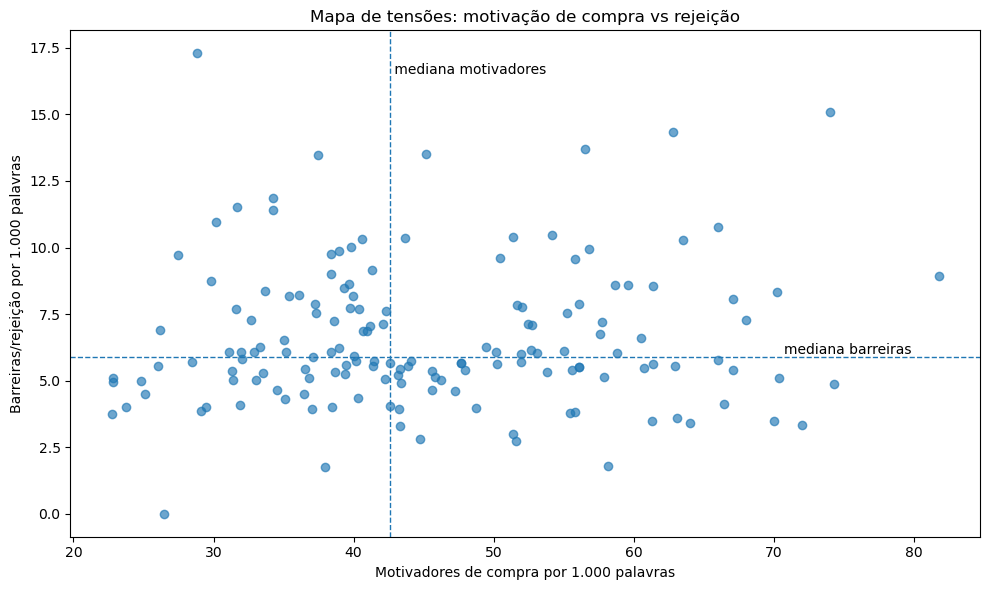

In [7]:
# Quadrantes acionáveis
q_mot = scored["motivadores_total_per_1k"].median()
q_bar = scored["barreiras_total_per_1k"].median()

def quadrant(row):
    mot = row["motivadores_total_per_1k"]
    bar = row["barreiras_total_per_1k"]
    if mot >= q_mot and bar >= q_bar:
        return "alta_motivacao_alta_barreira"
    if mot >= q_mot and bar < q_bar:
        return "alta_motivacao_baixa_barreira"
    if mot < q_mot and bar >= q_bar:
        return "baixa_motivacao_alta_barreira"
    return "baixa_motivacao_baixa_barreira"

scored["quadrante_tensao"] = scored.apply(quadrant, axis=1)

quad_summary = (
    scored.groupby("quadrante_tensao")
    .agg(
        n_entrevistas=("doc_id", "count"),
        motivadores_medios=("motivadores_total_per_1k", "mean"),
        barreiras_medias=("barreiras_total_per_1k", "mean"),
        saldo_medio=("saldo_compra_rejeicao", "mean"),
    )
    .reset_index()
    .sort_values("n_entrevistas", ascending=False)
)
quad_summary["share_%"] = 100 * quad_summary["n_entrevistas"] / quad_summary["n_entrevistas"].sum()
save_csv(quad_summary, "mapa_tensoes_quadrantes.csv")
display(quad_summary)

plt.figure(figsize=(10, 6))
plt.scatter(scored["motivadores_total_per_1k"], scored["barreiras_total_per_1k"], alpha=0.65)
plt.axvline(q_mot, linestyle="--", linewidth=1)
plt.axhline(q_bar, linestyle="--", linewidth=1)
plt.xlabel("Motivadores de compra por 1.000 palavras")
plt.ylabel("Barreiras/rejeição por 1.000 palavras")
plt.title("Mapa de tensões: motivação de compra vs rejeição")
plt.text(q_mot, scored["barreiras_total_per_1k"].max()*0.98, " mediana motivadores", va="top")
plt.text(scored["motivadores_total_per_1k"].max()*0.98, q_bar, "mediana barreiras ", ha="right", va="bottom")
save_fig("mapa_tensoes_compra_vs_rejeicao.png")
plt.show()

## 8. Motivadores e barreiras mais relevantes

salvo: /Users/emanuelgandra/Desktop/Faculdade/6Período/Kyra/kyrapesquisa/Kyra Atual/outputs/tensoes_jtbd/tables/motivadores_barreiras_resumo.csv


,tipo,dimensao,media_per_1k,mediana_per_1k,pct_entrevistas_com_mencao,total_hits_norm
0,motivador,marca_confianca_memoria,11.109148,10.305429,98.709677,1721.918013
1,motivador,canal_conveniencia_consultora,9.346314,6.720696,100.000000,1448.678702
2,motivador,presente_status_estetica,7.070004,4.719427,98.064516,1095.850550
3,motivador,eficacia_resultado_prova,4.726977,3.244519,96.774194,732.681366
4,motivador,sensorial_experiencia,4.283808,3.783431,98.064516,663.990233
5,motivador,indicacao_social_familiar,3.456889,2.699359,98.709677,535.817813
6,motivador,natural_sustentavel_ingredientes,2.795965,1.386351,90.322581,433.374518
7,motivador,preco_valor_promocao,2.601235,1.563174,95.483871,403.191434
8,barreira,indecisao_excesso_opcoes,2.714689,2.471984,98.709677,420.776864
9,barreira,preco_alto_sem_valor,2.270553,1.681520,94.838710,351.935665


salvo: /Users/emanuelgandra/Desktop/Faculdade/6Período/Kyra/kyrapesquisa/Kyra Atual/outputs/tensoes_jtbd/figures/motivadores_compra_media.png


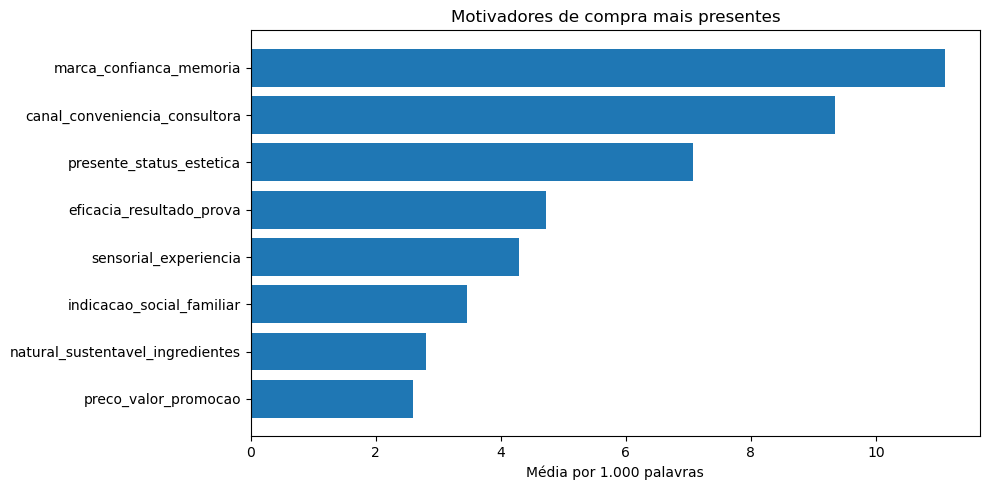

salvo: /Users/emanuelgandra/Desktop/Faculdade/6Período/Kyra/kyrapesquisa/Kyra Atual/outputs/tensoes_jtbd/figures/barreiras_rejeicao_media.png


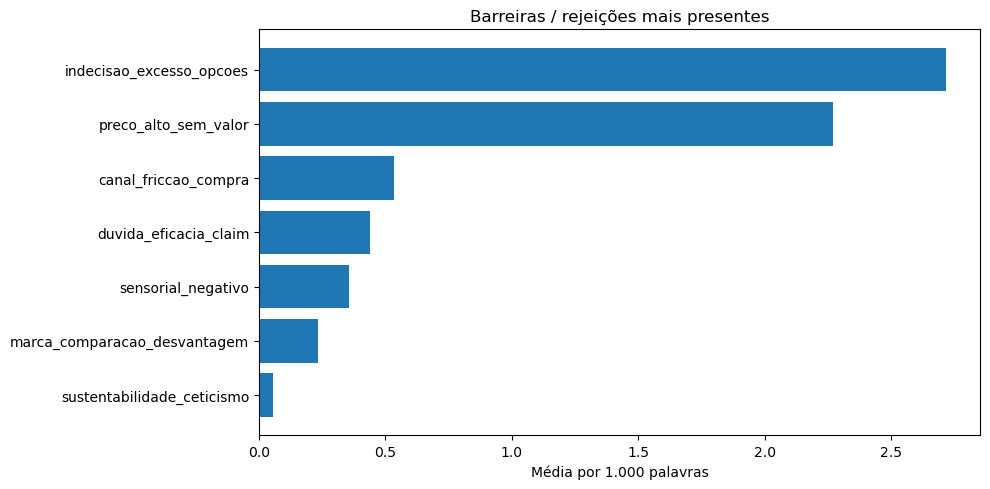

In [8]:
def summarize_dimension_group(df, cols, prefix, label):
    rows = []
    for c in cols:
        dim = c.replace(prefix, "").replace("_per_1k", "")
        rows.append({
            "tipo": label,
            "dimensao": dim,
            "media_per_1k": df[c].mean(),
            "mediana_per_1k": df[c].median(),
            "pct_entrevistas_com_mencao": 100 * (df[c] > 0).mean(),
            "total_hits_norm": df[c].sum(),
        })
    return pd.DataFrame(rows).sort_values(["tipo", "media_per_1k"], ascending=[True, False])

mot_summary = summarize_dimension_group(scored, mot_cols, "mot__", "motivador")
bar_summary = summarize_dimension_group(scored, bar_cols, "bar__", "barreira")
tension_dims_summary = pd.concat([mot_summary, bar_summary], ignore_index=True)
save_csv(tension_dims_summary, "motivadores_barreiras_resumo.csv")
display(tension_dims_summary)

# Gráficos separados para não poluir
plot_mot = mot_summary.sort_values("media_per_1k", ascending=True)
plt.figure(figsize=(10, 5))
plt.barh(plot_mot["dimensao"], plot_mot["media_per_1k"])
plt.xlabel("Média por 1.000 palavras")
plt.title("Motivadores de compra mais presentes")
save_fig("motivadores_compra_media.png")
plt.show()

plot_bar = bar_summary.sort_values("media_per_1k", ascending=True)
plt.figure(figsize=(10, 5))
plt.barh(plot_bar["dimensao"], plot_bar["media_per_1k"])
plt.xlabel("Média por 1.000 palavras")
plt.title("Barreiras / rejeições mais presentes")
save_fig("barreiras_rejeicao_media.png")
plt.show()

## 9. Matriz de tensão: qual motivador convive com qual barreira

salvo: /Users/emanuelgandra/Desktop/Faculdade/6Período/Kyra/kyrapesquisa/Kyra Atual/outputs/tensoes_jtbd/tables/matriz_tensao_motivador_x_barreira_counts.csv
salvo: /Users/emanuelgandra/Desktop/Faculdade/6Período/Kyra/kyrapesquisa/Kyra Atual/outputs/tensoes_jtbd/tables/matriz_tensao_motivador_x_barreira_pct_linha.csv


barreira_principal,canal_friccao_compra,indecisao_excesso_opcoes,marca_comparacao_desvantagem,nao_identificado,preco_alto_sem_valor,sensorial_negativo
motivador_principal,,,,,,
canal_conveniencia_consultora,1,21,0,1,3,0
eficacia_resultado_prova,0,14,0,0,6,1
indicacao_social_familiar,0,4,0,0,2,0
marca_confianca_memoria,1,37,2,0,23,0
presente_status_estetica,0,16,0,0,21,0
sensorial_experiencia,0,1,0,0,1,0


salvo: /Users/emanuelgandra/Desktop/Faculdade/6Período/Kyra/kyrapesquisa/Kyra Atual/outputs/tensoes_jtbd/figures/matriz_tensao_motivador_x_barreira.png


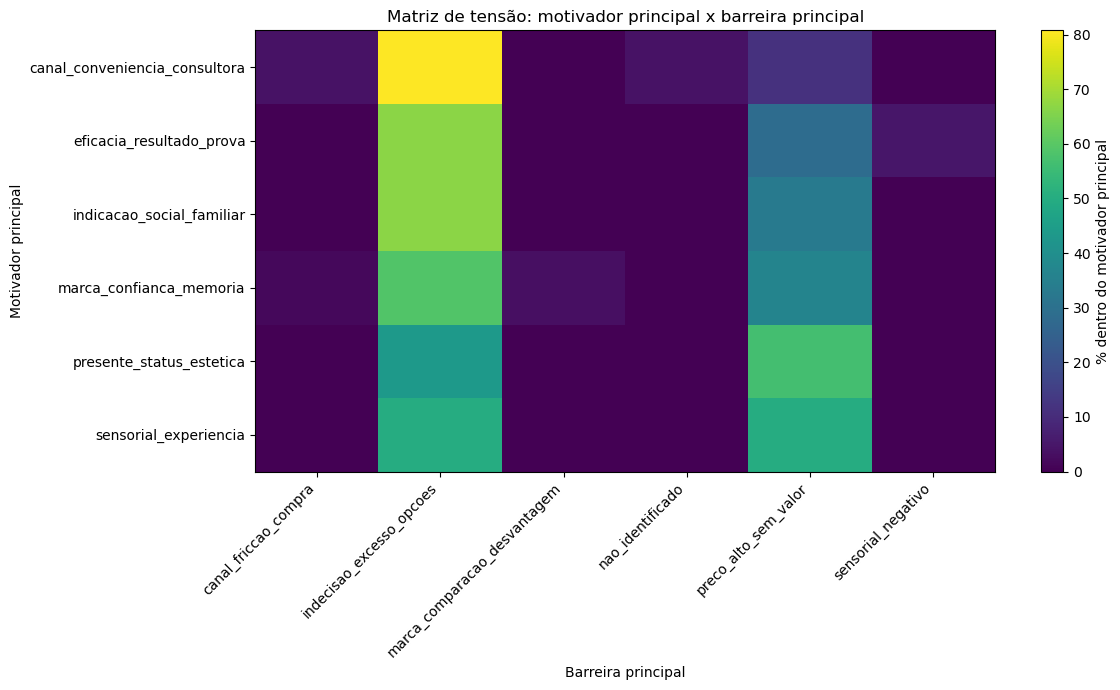

In [9]:
# Matriz baseada no principal motivador e principal barreira de cada entrevista.
tension_matrix = pd.crosstab(scored["motivador_principal"], scored["barreira_principal"])
tension_matrix_pct = tension_matrix.div(tension_matrix.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100

save_csv(tension_matrix.reset_index(), "matriz_tensao_motivador_x_barreira_counts.csv")
save_csv(tension_matrix_pct.reset_index(), "matriz_tensao_motivador_x_barreira_pct_linha.csv")
display(tension_matrix)

plt.figure(figsize=(12, 7))
plt.imshow(tension_matrix_pct.values, aspect="auto")
plt.xticks(range(len(tension_matrix_pct.columns)), tension_matrix_pct.columns, rotation=45, ha="right")
plt.yticks(range(len(tension_matrix_pct.index)), tension_matrix_pct.index)
plt.colorbar(label="% dentro do motivador principal")
plt.title("Matriz de tensão: motivador principal x barreira principal")
plt.xlabel("Barreira principal")
plt.ylabel("Motivador principal")
save_fig("matriz_tensao_motivador_x_barreira.png")
plt.show()

## 10. Jobs-to-be-Done

salvo: /Users/emanuelgandra/Desktop/Faculdade/6Período/Kyra/kyrapesquisa/Kyra Atual/outputs/tensoes_jtbd/tables/jtbd_resumo.csv


,dimensao,media_per_1k,mediana_per_1k,pct_entrevistas_com_mencao,total_hits_norm
8,compra_conveniente_e_acesso,7.353559,5.404188,98.709677,1139.801691
0,presentear_e_demonstrar_cuidado,4.407332,1.249357,95.483871,683.136485
6,experiencia_sensorial_prazer_ritual,4.062338,3.375527,98.064516,629.662423
4,cuidado_familiar_e_social,3.776181,2.646956,97.419355,585.308106
7,pertencimento_recomendacao_comunidade,3.097306,2.383122,94.838710,480.082455
3,eficacia_tratamento_resolver_problema,2.080378,1.276324,95.483871,322.458576
2,praticidade_rotina_rapida,1.874851,1.529690,98.064516,290.601918
5,economizar_sem_perder_qualidade,1.099439,0.468604,84.516129,170.413077
1,autoestima_e_expressao_identidade,0.553173,0.217226,70.967742,85.741878


salvo: /Users/emanuelgandra/Desktop/Faculdade/6Período/Kyra/kyrapesquisa/Kyra Atual/outputs/tensoes_jtbd/tables/jtbd_principal_distribuicao.csv


,jtbd_principal,n_entrevistas,motivacao_media,barreira_media,saldo_medio,share_%
0,compra_conveniente_e_acesso,47,51.373661,6.613179,44.760483,30.322581
3,experiencia_sensorial_prazer_ritual,37,38.856550,7.029665,31.826885,23.870968
6,presentear_e_demonstrar_cuidado,30,53.737982,6.623023,47.114959,19.354839
2,eficacia_tratamento_resolver_problema,17,37.585946,5.678083,31.907863,10.967742
1,cuidado_familiar_e_social,13,37.714280,6.119085,31.595195,8.387097
5,praticidade_rotina_rapida,6,42.543871,7.652517,34.891353,3.870968
4,pertencimento_recomendacao_comunidade,5,37.319760,6.232282,31.087478,3.225806


salvo: /Users/emanuelgandra/Desktop/Faculdade/6Período/Kyra/kyrapesquisa/Kyra Atual/outputs/tensoes_jtbd/figures/jtbd_media.png


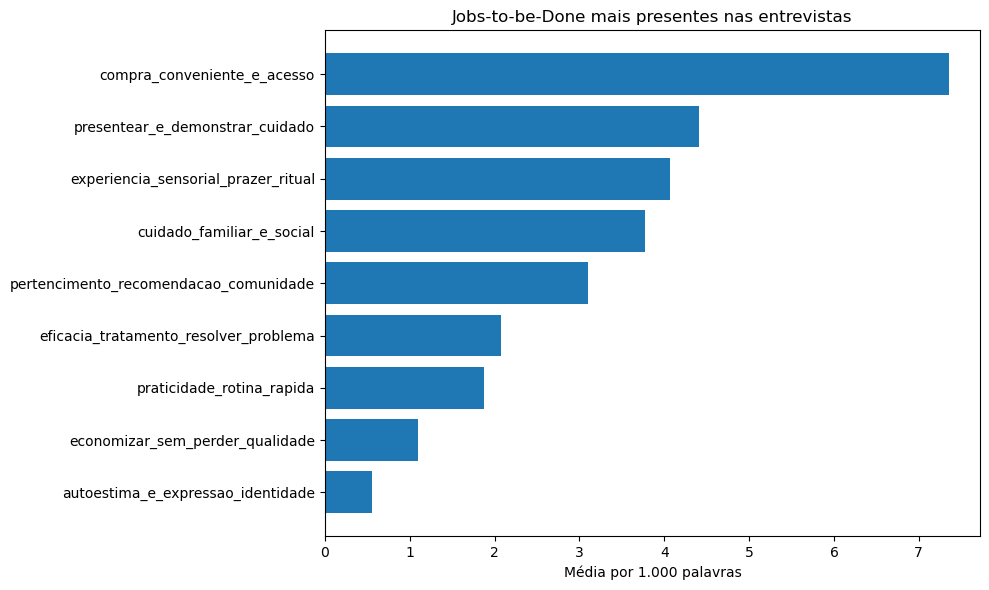

In [10]:
jtbd_summary = summarize_dimension_group(scored, jtbd_cols, "jtbd__", "jtbd")
jtbd_summary = jtbd_summary.drop(columns=["tipo"])
save_csv(jtbd_summary, "jtbd_resumo.csv")
display(jtbd_summary)

jtbd_dist = (
    scored.groupby("jtbd_principal")
    .agg(n_entrevistas=("doc_id", "count"), motivacao_media=("motivadores_total_per_1k", "mean"), barreira_media=("barreiras_total_per_1k", "mean"), saldo_medio=("saldo_compra_rejeicao", "mean"))
    .reset_index()
    .sort_values("n_entrevistas", ascending=False)
)
jtbd_dist["share_%"] = 100 * jtbd_dist["n_entrevistas"] / jtbd_dist["n_entrevistas"].sum()
save_csv(jtbd_dist, "jtbd_principal_distribuicao.csv")
display(jtbd_dist)

plot_jtbd = jtbd_summary.sort_values("media_per_1k", ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(plot_jtbd["dimensao"], plot_jtbd["media_per_1k"])
plt.xlabel("Média por 1.000 palavras")
plt.title("Jobs-to-be-Done mais presentes nas entrevistas")
save_fig("jtbd_media.png")
plt.show()

## 11. Evidências citáveis por dimensão

In [11]:
def sentence_hit_score(sent: str, patterns) -> int:
    """Score rápido para evidências. Usa substring normalizada para frases e termos."""
    s = norm_text(sent)
    if not s:
        return 0
    hits = 0
    for pat in patterns:
        p = norm_text(pat)
        if not p:
            continue
        # Para evidência, substring é suficiente e muito mais rápido que regex exaustivo.
        hits += s.count(p)
    return hits


def extract_best_evidence(df, dim_name, patterns, score_col, text_col="analysis_text", top_docs=18, top_n=8):
    """Extrai evidências apenas das entrevistas com maior score daquela dimensão.
    Isso evita varrer todas as frases de todos os documentos para todas as dimensões.
    """
    if score_col not in df.columns:
        return pd.DataFrame()
    candidates = df[df[score_col] > 0].sort_values(score_col, ascending=False).head(top_docs)
    rows = []
    for _, row in candidates.iterrows():
        sents = split_sentences(row[text_col])
        best_sent = None
        best_score = 0
        for sent in sents[:500]:  # proteção para transcrições muito longas
            h = sentence_hit_score(sent, patterns)
            if h > best_score:
                best_score = h
                best_sent = sent
        if best_sent and best_score > 0:
            out = {
                "doc_id": row["doc_id"],
                "dimensao": dim_name,
                "score_doc_per_1k": row[score_col],
                "hits_na_frase": best_score,
                "evidencia": snippet(best_sent, 500),
            }
            for c in metadata_cols:
                out[c] = row.get(c, np.nan)
            if persona_col:
                out[persona_col] = row.get(persona_col, np.nan)
            rows.append(out)
    ev = pd.DataFrame(rows)
    if ev.empty:
        return ev
    return ev.sort_values(["score_doc_per_1k", "hits_na_frase"], ascending=False).head(top_n)

all_evidence_parts = []
for k, pats in BUY_MOTIVATORS.items():
    all_evidence_parts.append(extract_best_evidence(scored, "motivador__" + k, pats, f"mot__{k}_per_1k", top_n=6))
for k, pats in REJECTION_BARRIERS.items():
    all_evidence_parts.append(extract_best_evidence(scored, "barreira__" + k, pats, f"bar__{k}_per_1k", top_n=6))
for k, pats in JTBD.items():
    all_evidence_parts.append(extract_best_evidence(scored, "jtbd__" + k, pats, f"jtbd__{k}_per_1k", top_n=6))

evidence = pd.concat([x for x in all_evidence_parts if x is not None and not x.empty], ignore_index=True) if all_evidence_parts else pd.DataFrame()
save_csv(evidence, "evidencias_citaveis_por_dimensao.csv")
display(evidence.head(20))

salvo: /Users/emanuelgandra/Desktop/Faculdade/6Período/Kyra/kyrapesquisa/Kyra Atual/outputs/tensoes_jtbd/tables/evidencias_citaveis_por_dimensao.csv


,doc_id,dimensao,score_doc_per_1k,hits_na_frase,evidencia,projeto,pais,marca_foco,publico,tipo_sessao,canal_origem,idioma_original,persona_nome_auto
0,doc_5c06d290f301eadb,motivador__preco_valor_promocao,14.733347,4,"Então, assim, a oferta de produtos da Natura em relação a a esses itens de higiene pessoal melhor, mais diversificada do que a do Boticário com preço mais afetível, porque todo tipo tem outro em promoção.",natura_3cs,nao_inferido,natura,consultoras,nao_inferido,m4a,pt,sem_persona_rodar_notebook_04
1,doc_a966111a7b9eb0a6,motivador__preco_valor_promocao,14.337508,5,A Naturo faturamento ela é pouco maior né a Boticário já não traz tanto esse faturamento só traz assim quando você pega as ofertas como eu falei né aí sim você consegue faturar no próximo ciclo porque aí você já vai ...,natura_3cs,nao_inferido,natura,consultoras,nao_inferido,m4a,pt,sem_persona_rodar_notebook_04
2,doc_e9d9fb1438841663,motivador__preco_valor_promocao,11.941127,3,"Procuro não prejudicar a minha colega, porque eu sei que a minha colega também trabalha pouco, porque precisa, eu não vou dar desconto, que a pessoa ou o cliente dela vai ficar sabendo, vai vir comprar de mim, porque...",natura_3cs,nao_inferido,natura,consultoras,nao_inferido,m4a,pt,sem_persona_rodar_notebook_04
3,doc_f17a8b4e6ffe8287,motivador__preco_valor_promocao,11.630981,3,"Speaker 2 - Não, pra ser sincera, eu gosto bastante dos kits da Natura porque é uma das marcas que reduz mais o preço do kit.",natura_3cs,nao_inferido,natura,consultoras,nao_inferido,m4a,pt,sem_persona_rodar_notebook_04
4,doc_9852515aa99fe494,motivador__preco_valor_promocao,10.434499,3,"O produto baixou, o produto tá em oferta, o preço baixou.",compras_digitais,nao_inferido,nao_inferido,nao_inferido,nao_inferido,m4a,pt,sem_persona_rodar_notebook_04
5,doc_012fe174842b390e,motivador__preco_valor_promocao,9.499537,4,Vendi baixa inclusive para você ter ideia eu fiz pedido na quinta-feira que era kit de namorados me pergunta hoje o que tem desses kit de namorado e que tem kit da Boticário por exemplo eu pedi eu acho foram 26 kit n...,natura_3cs,nao_inferido,natura,consultoras,nao_inferido,m4a,pt,sem_persona_rodar_notebook_04
6,doc_3d71a73387cbd4a7,motivador__eficacia_resultado_prova,25.993225,9,"Speaker 1 - E Tainá, me fala uma coisa, o hidratante todo dia que você vende, o hidratante é todo dia ou tem mais alguma marca que você vende de hidratante?",radiosa,nao_inferido,nao_inferido,nao_inferido,nao_inferido,m4a,pt,sem_persona_rodar_notebook_04
7,doc_c3440e03873d8788,motivador__eficacia_resultado_prova,17.895600,7,"E só mais uma coisa que eu quero saber, porque, Elizabeth, depois eu quero ouvir das outras, mas assim, quando você falou do hidratante, que você gosta de todo dia, porque ele absorveu e deixou resultado legal, o que...",radiosa,nao_inferido,nao_inferido,nao_inferido,nao_inferido,m4a,pt,sem_persona_rodar_notebook_04
8,doc_c1b714ce1513e838,motivador__eficacia_resultado_prova,16.331948,4,"Speaker 6 - Eu vejo que tem resultado dos produtos ali, e só pelo rosto semblante delas dá para ver que é eficaz o produto.",gaia_ii,nao_inferido,nao_inferido,nao_inferido,nao_inferido,pdf,pt,sem_persona_rodar_notebook_04
9,doc_b71f944ee9bec4b0,motivador__eficacia_resultado_prova,16.204914,9,"Então, com ECOS, ele viria aí com hidratante, mas talvez esse hidratante teria óleo no hidratante, teria outro tipo de produto aí.",radiosa,nao_inferido,nao_inferido,nao_inferido,nao_inferido,m4a,pt,sem_persona_rodar_notebook_04


## 12. Cruzamentos por persona e metadados

In [12]:
# Cruzamento com personas, se disponível
if persona_col:
    persona_tension = (
        scored.groupby(persona_col)
        .agg(
            n_entrevistas=("doc_id", "count"),
            motivadores_media=("motivadores_total_per_1k", "mean"),
            barreiras_media=("barreiras_total_per_1k", "mean"),
            saldo_medio=("saldo_compra_rejeicao", "mean"),
            intensidade_tensao_media=("intensidade_tensao", "mean"),
        )
        .reset_index()
        .sort_values("n_entrevistas", ascending=False)
    )
    save_csv(persona_tension, "tensoes_por_persona.csv")
    display(persona_tension)

    persona_jtbd = pd.crosstab(scored[persona_col], scored["jtbd_principal"], normalize="index") * 100
    save_csv(persona_jtbd.reset_index(), "jtbd_principal_por_persona_pct.csv")
    display(persona_jtbd)

# Cruzamentos com metadados selecionados
cross_rows = []
for seg in metadata_cols + ([persona_col] if persona_col else []):
    if not seg or seg not in scored.columns:
        continue
    tmp = scored.groupby(seg).agg(
        n_entrevistas=("doc_id", "count"),
        motivadores_media=("motivadores_total_per_1k", "mean"),
        barreiras_media=("barreiras_total_per_1k", "mean"),
        saldo_medio=("saldo_compra_rejeicao", "mean"),
        jtbd_top=("jtbd_principal", lambda x: x.value_counts().index[0] if len(x.dropna()) else np.nan),
        motivador_top=("motivador_principal", lambda x: x.value_counts().index[0] if len(x.dropna()) else np.nan),
        barreira_top=("barreira_principal", lambda x: x.value_counts().index[0] if len(x.dropna()) else np.nan),
    ).reset_index().rename(columns={seg: "segmento_valor"})
    tmp.insert(0, "segmento_coluna", seg)
    cross_rows.append(tmp)

segments_summary = pd.concat(cross_rows, ignore_index=True) if cross_rows else pd.DataFrame()
if not segments_summary.empty:
    segments_summary = segments_summary.sort_values(["segmento_coluna", "n_entrevistas"], ascending=[True, False])
    save_csv(segments_summary, "tensoes_jtbd_por_segmentos.csv")
    display(segments_summary.head(30))

salvo: /Users/emanuelgandra/Desktop/Faculdade/6Período/Kyra/kyrapesquisa/Kyra Atual/outputs/tensoes_jtbd/tables/tensoes_por_persona.csv


,persona_nome_auto,n_entrevistas,motivadores_media,barreiras_media,saldo_medio,intensidade_tensao_media
0,sem_persona_rodar_notebook_04,155,45.39034,6.59845,38.79189,51.988789


salvo: /Users/emanuelgandra/Desktop/Faculdade/6Período/Kyra/kyrapesquisa/Kyra Atual/outputs/tensoes_jtbd/tables/jtbd_principal_por_persona_pct.csv


jtbd_principal,compra_conveniente_e_acesso,cuidado_familiar_e_social,eficacia_tratamento_resolver_problema,experiencia_sensorial_prazer_ritual,pertencimento_recomendacao_comunidade,praticidade_rotina_rapida,presentear_e_demonstrar_cuidado
persona_nome_auto,,,,,,,
sem_persona_rodar_notebook_04,30.322581,8.387097,10.967742,23.870968,3.225806,3.870968,19.354839


salvo: /Users/emanuelgandra/Desktop/Faculdade/6Período/Kyra/kyrapesquisa/Kyra Atual/outputs/tensoes_jtbd/tables/tensoes_jtbd_por_segmentos.csv


,segmento_coluna,segmento_valor,n_entrevistas,motivadores_media,barreiras_media,saldo_medio,jtbd_top,motivador_top,barreira_top
25,canal_origem,m4a,94,50.195158,6.425509,43.769649,compra_conveniente_e_acesso,marca_confianca_memoria,indecisao_excesso_opcoes
26,canal_origem,pdf,61,37.986193,6.864948,31.121245,experiencia_sensorial_prazer_ritual,marca_confianca_memoria,indecisao_excesso_opcoes
28,idioma_original,pt,134,46.720918,6.571863,40.149055,compra_conveniente_e_acesso,marca_confianca_memoria,indecisao_excesso_opcoes
27,idioma_original,es,21,36.899983,6.768101,30.131882,experiencia_sensorial_prazer_ritual,marca_confianca_memoria,indecisao_excesso_opcoes
17,marca_foco,nao_inferido,100,41.486484,6.427630,35.058854,compra_conveniente_e_acesso,marca_confianca_memoria,indecisao_excesso_opcoes
18,marca_foco,natura,52,53.150457,6.620241,46.530216,presentear_e_demonstrar_cuidado,presente_status_estetica,indecisao_excesso_opcoes
16,marca_foco,concorrencia,3,41.010158,11.914718,29.095440,experiencia_sensorial_prazer_ritual,marca_confianca_memoria,marca_comparacao_desvantagem
15,pais,nao_inferido,124,46.847239,6.643993,40.203246,compra_conveniente_e_acesso,marca_confianca_memoria,indecisao_excesso_opcoes
13,pais,brasil,14,39.642215,5.424633,34.217583,experiencia_sensorial_prazer_ritual,marca_confianca_memoria,indecisao_excesso_opcoes
14,pais,mexico,10,36.626775,7.243409,29.383367,experiencia_sensorial_prazer_ritual,marca_confianca_memoria,indecisao_excesso_opcoes


## 13. Oportunidades estratégicas por JTBD e tensão

In [13]:
OPPORTUNITY_RULES = {
    "presentear_e_demonstrar_cuidado": {
        "produto": "Criar kits prontos para presente, faixas de preço claras e embalagens presenteáveis.",
        "comunicacao": "Comunicar cuidado, afeto, ocasião e facilidade de acertar no presente.",
        "canal": "Destacar compra rápida por WhatsApp/consultora/loja e disponibilidade perto de datas comemorativas.",
    },
    "autoestima_e_expressao_identidade": {
        "produto": "Priorizar sortimento inclusivo, tons/necessidades específicas e benefícios ligados à confiança.",
        "comunicacao": "Usar linguagem de identificação, representatividade e transformação pessoal sem exagero de promessa.",
        "canal": "Amostras, demonstração e conteúdo com pessoas parecidas com o público-alvo.",
    },
    "praticidade_rotina_rapida": {
        "produto": "Simplificar rotinas, formatos fáceis, multifuncionais e instruções de uso objetivas.",
        "comunicacao": "Falar de economia de tempo, facilidade e encaixe no dia a dia.",
        "canal": "Recompra fácil, assinatura, lembrete e navegação objetiva no digital.",
    },
    "eficacia_tratamento_resolver_problema": {
        "produto": "Reforçar ativos, prova de eficácia, testes e benefícios mensuráveis.",
        "comunicacao": "Explicar o mecanismo de ação com clareza, sem prometer milagre.",
        "canal": "Demonstrações, antes/depois responsável, reviews e orientação de consultora/especialista.",
    },
    "cuidado_familiar_e_social": {
        "produto": "Criar produtos/combos para uso compartilhado, família ou cuidado com filhos/mães.",
        "comunicacao": "Comunicar cuidado prático, proteção e carinho no contexto familiar.",
        "canal": "Campanhas em datas familiares e venda consultiva com recomendação pessoal.",
    },
    "economizar_sem_perder_qualidade": {
        "produto": "Oferecer refil, tamanho econômico, kit e comparação de rendimento.",
        "comunicacao": "Traduzir preço em valor: rendimento, durabilidade, desconto e qualidade.",
        "canal": "Promos claras, bundles e régua de recompra.",
    },
    "experiencia_sensorial_prazer_ritual": {
        "produto": "Investir em fragrância, textura, toque, embalagem e experiência de aplicação.",
        "comunicacao": "Comunicar sensações concretas e ritual de uso.",
        "canal": "Experimentação em loja, amostras e descrições sensoriais fortes no digital.",
    },
    "pertencimento_recomendacao_comunidade": {
        "produto": "Criar produtos fáceis de recomendar e compartilhar em grupos.",
        "comunicacao": "Usar prova social, resenhas e histórias reais.",
        "canal": "Ativar consultoras, influenciadoras e mecanismos de indicação.",
    },
    "compra_conveniente_e_acesso": {
        "produto": "Garantir disponibilidade, kits simples e clareza de variantes.",
        "comunicacao": "Falar de facilidade de comprar, receber e recomprar.",
        "canal": "Reduzir fricção de site/app/link, frete, entrega e estoque.",
    },
}

BARRIER_ACTIONS = {
    "preco_alto_sem_valor": "Mostrar valor de forma objetiva: rendimento, comparação, kits, refil, preço por uso e desconto transparente.",
    "duvida_eficacia_claim": "Reduzir ceticismo com prova, explicação simples, testes, reviews e claims menos genéricos.",
    "sensorial_negativo": "Trabalhar amostras, descrição sensorial honesta e alternativas por preferência de cheiro/textura.",
    "canal_friccao_compra": "Remover atritos de acesso: frete, entrega, estoque, link, app/site e clareza de onde comprar.",
    "marca_comparacao_desvantagem": "Enfrentar comparação com concorrentes por benefício específico, não só por marca.",
    "sustentabilidade_ceticismo": "Tornar sustentabilidade concreta: impacto, refil fácil, economia e explicação sem tom genérico.",
    "indecisao_excesso_opcoes": "Simplificar escolha com guias, recomendação por necessidade e poucos caminhos claros de decisão.",
    "nao_identificado": "Ler evidências qualitativas e complementar dicionário de barreiras.",
}

opp_rows = []
for _, row in jtbd_dist.iterrows():
    j = row["jtbd_principal"]
    rules = OPPORTUNITY_RULES.get(j, {})
    # barreira mais comum entre entrevistas deste JTBD
    sub = scored[scored["jtbd_principal"] == j]
    bar_top = sub["barreira_principal"].value_counts().index[0] if len(sub) else "nao_identificado"
    mot_top = sub["motivador_principal"].value_counts().index[0] if len(sub) else "nao_identificado"
    opp_rows.append({
        "jtbd": j,
        "n_entrevistas": int(row["n_entrevistas"]),
        "share_%": row["share_%"],
        "motivador_mais_associado": mot_top,
        "barreira_mais_associada": bar_top,
        "oportunidade_produto": rules.get("produto", "Revisar evidências e criar hipótese específica."),
        "oportunidade_comunicacao": rules.get("comunicacao", "Revisar linguagem usada pelos entrevistados."),
        "oportunidade_canal": rules.get("canal", "Revisar jornada e pontos de contato mencionados."),
        "acao_para_barreira": BARRIER_ACTIONS.get(bar_top, "Revisar evidências qualitativas."),
    })

opportunities = pd.DataFrame(opp_rows).sort_values("n_entrevistas", ascending=False)
save_csv(opportunities, "oportunidades_por_jtbd.csv")
display(opportunities)

salvo: /Users/emanuelgandra/Desktop/Faculdade/6Período/Kyra/kyrapesquisa/Kyra Atual/outputs/tensoes_jtbd/tables/oportunidades_por_jtbd.csv


,jtbd,n_entrevistas,share_%,motivador_mais_associado,barreira_mais_associada,oportunidade_produto,oportunidade_comunicacao,oportunidade_canal,acao_para_barreira
0,compra_conveniente_e_acesso,47,30.322581,canal_conveniencia_consultora,indecisao_excesso_opcoes,"Garantir disponibilidade, kits simples e clareza de variantes.","Falar de facilidade de comprar, receber e recomprar.","Reduzir fricção de site/app/link, frete, entrega e estoque.","Simplificar escolha com guias, recomendação por necessidade e poucos caminhos claros de decisão."
1,experiencia_sensorial_prazer_ritual,37,23.870968,marca_confianca_memoria,indecisao_excesso_opcoes,"Investir em fragrância, textura, toque, embalagem e experiência de aplicação.",Comunicar sensações concretas e ritual de uso.,"Experimentação em loja, amostras e descrições sensoriais fortes no digital.","Simplificar escolha com guias, recomendação por necessidade e poucos caminhos claros de decisão."
2,presentear_e_demonstrar_cuidado,30,19.354839,presente_status_estetica,indecisao_excesso_opcoes,"Criar kits prontos para presente, faixas de preço claras e embalagens presenteáveis.","Comunicar cuidado, afeto, ocasião e facilidade de acertar no presente.",Destacar compra rápida por WhatsApp/consultora/loja e disponibilidade perto de datas comemorativas.,"Simplificar escolha com guias, recomendação por necessidade e poucos caminhos claros de decisão."
3,eficacia_tratamento_resolver_problema,17,10.967742,eficacia_resultado_prova,preco_alto_sem_valor,"Reforçar ativos, prova de eficácia, testes e benefícios mensuráveis.","Explicar o mecanismo de ação com clareza, sem prometer milagre.","Demonstrações, antes/depois responsável, reviews e orientação de consultora/especialista.","Mostrar valor de forma objetiva: rendimento, comparação, kits, refil, preço por uso e desconto transparente."
4,cuidado_familiar_e_social,13,8.387097,marca_confianca_memoria,preco_alto_sem_valor,"Criar produtos/combos para uso compartilhado, família ou cuidado com filhos/mães.","Comunicar cuidado prático, proteção e carinho no contexto familiar.",Campanhas em datas familiares e venda consultiva com recomendação pessoal.,"Mostrar valor de forma objetiva: rendimento, comparação, kits, refil, preço por uso e desconto transparente."
5,praticidade_rotina_rapida,6,3.870968,marca_confianca_memoria,indecisao_excesso_opcoes,"Simplificar rotinas, formatos fáceis, multifuncionais e instruções de uso objetivas.","Falar de economia de tempo, facilidade e encaixe no dia a dia.","Recompra fácil, assinatura, lembrete e navegação objetiva no digital.","Simplificar escolha com guias, recomendação por necessidade e poucos caminhos claros de decisão."
6,pertencimento_recomendacao_comunidade,5,3.225806,marca_confianca_memoria,indecisao_excesso_opcoes,Criar produtos fáceis de recomendar e compartilhar em grupos.,"Usar prova social, resenhas e histórias reais.","Ativar consultoras, influenciadoras e mecanismos de indicação.","Simplificar escolha com guias, recomendação por necessidade e poucos caminhos claros de decisão."


## 14. Classificador de nova entrevista

In [14]:
def analyze_new_interview(text: str, top_n=5) -> dict:
    """Retorna diagnóstico de motivadores, barreiras e JTBD para uma nova entrevista."""
    text = str(text or "")
    n_words = max(len(text.split()), 1)
    rows = []
    for group_name, dct, prefix in [
        ("motivador", BUY_MOTIVATORS, "mot"),
        ("barreira", REJECTION_BARRIERS, "bar"),
        ("jtbd", JTBD, "jtbd"),
    ]:
        for dim, pats in dct.items():
            hits = count_pattern_hits(text, pats)
            rows.append({
                "tipo": group_name,
                "dimensao": dim,
                "hits": hits,
                "score_per_1k": 1000 * hits / n_words,
            })
    res = pd.DataFrame(rows)
    # Percentual de aderência dentro de cada tipo
    res["aderencia_%"] = 0.0
    for tipo in res["tipo"].unique():
        mask = res["tipo"] == tipo
        denom = res.loc[mask, "score_per_1k"].sum()
        if denom > 0:
            res.loc[mask, "aderencia_%"] = 100 * res.loc[mask, "score_per_1k"] / denom
    res = res.sort_values(["tipo", "aderencia_%", "score_per_1k"], ascending=[True, False, False])

    mot_total = res.loc[res["tipo"] == "motivador", "score_per_1k"].sum()
    bar_total = res.loc[res["tipo"] == "barreira", "score_per_1k"].sum()
    summary = {
        "n_words": n_words,
        "motivadores_total_per_1k": mot_total,
        "barreiras_total_per_1k": bar_total,
        "saldo_compra_rejeicao": mot_total - bar_total,
        "diagnostico_tensao": "mais_compra_que_rejeicao" if mot_total > bar_total else "mais_rejeicao_ou_ceticismo",
        "tabela": res,
    }
    return summary

# Cole uma entrevista nova aqui para testar.
NEW_INTERVIEW_TEXT = """
Cole aqui o texto de uma nova entrevista para classificar motivadores, barreiras e Jobs-to-be-Done.
"""

new_result = analyze_new_interview(NEW_INTERVIEW_TEXT)
print({k: v for k, v in new_result.items() if k != "tabela"})
display(new_result["tabela"].groupby("tipo", group_keys=False).head(5))

{'n_words': 14, 'motivadores_total_per_1k': 71.42857142857143, 'barreiras_total_per_1k': 0.0, 'saldo_compra_rejeicao': 71.42857142857143, 'diagnostico_tensao': 'mais_compra_que_rejeicao'}


,tipo,dimensao,hits,score_per_1k,aderencia_%
8,barreira,preco_alto_sem_valor,0,0.000000,0.0
9,barreira,duvida_eficacia_claim,0,0.000000,0.0
10,barreira,sensorial_negativo,0,0.000000,0.0
11,barreira,canal_friccao_compra,0,0.000000,0.0
12,barreira,marca_comparacao_desvantagem,0,0.000000,0.0
15,jtbd,presentear_e_demonstrar_cuidado,0,0.000000,0.0
16,jtbd,autoestima_e_expressao_identidade,0,0.000000,0.0
17,jtbd,praticidade_rotina_rapida,0,0.000000,0.0
18,jtbd,eficacia_tratamento_resolver_problema,0,0.000000,0.0
19,jtbd,cuidado_familiar_e_social,0,0.000000,0.0


## 15. Relatório executivo automático

In [15]:
def top_list(df, dim_col="dimensao", value_col="media_per_1k", n=5):
    if df.empty:
        return []
    return df.sort_values(value_col, ascending=False).head(n)[dim_col].tolist()

mot_top = top_list(mot_summary)
bar_top = top_list(bar_summary)
jtbd_top = jtbd_dist.head(5)["jtbd_principal"].tolist()
quad_top = quad_summary.sort_values("n_entrevistas", ascending=False).iloc[0]["quadrante_tensao"] if len(quad_summary) else "n/a"

lines = []
lines.append("# Relatório — Tensões, Motivadores e Jobs-to-be-Done")
lines.append("")
lines.append(f"Foram analisadas **{len(scored)} entrevistas** com texto suficiente.")
lines.append("")
lines.append("## Leitura executiva")
lines.append("")
lines.append(f"O quadrante de tensão mais frequente foi **{quad_top}**.")
lines.append("")
lines.append("### Principais motivadores de compra")
for x in mot_top:
    lines.append(f"- {x}")
lines.append("")
lines.append("### Principais barreiras/rejeições")
for x in bar_top:
    lines.append(f"- {x}")
lines.append("")
lines.append("### Jobs-to-be-Done mais frequentes")
for x in jtbd_top:
    lines.append(f"- {x}")
lines.append("")
lines.append("## Oportunidades prioritárias")
for _, r in opportunities.head(8).iterrows():
    lines.append(f"### {r['jtbd']}")
    lines.append(f"- Entrevistas: {int(r['n_entrevistas'])} ({r['share_%']:.1f}%)")
    lines.append(f"- Motivador associado: {r['motivador_mais_associado']}")
    lines.append(f"- Barreira associada: {r['barreira_mais_associada']}")
    lines.append(f"- Produto: {r['oportunidade_produto']}")
    lines.append(f"- Comunicação: {r['oportunidade_comunicacao']}")
    lines.append(f"- Canal: {r['oportunidade_canal']}")
    lines.append(f"- Ação para barreira: {r['acao_para_barreira']}")
    lines.append("")

if evidence is not None and not evidence.empty:
    lines.append("## Evidências exemplares")
    for _, r in evidence.head(20).iterrows():
        meta = ", ".join([str(r.get(c, "")) for c in metadata_cols if c in r and pd.notna(r.get(c))])
        lines.append(f"- **{r['dimensao']}** — {r['evidencia']} _{meta}_")

report_path = REPORT_DIR / "relatorio_tensoes_jtbd.md"
report_path.write_text("\n".join(lines), encoding="utf-8")
print("salvo:", report_path)
print("\n".join(lines[:60]))

salvo: /Users/emanuelgandra/Desktop/Faculdade/6Período/Kyra/kyrapesquisa/Kyra Atual/outputs/tensoes_jtbd/reports/relatorio_tensoes_jtbd.md
# Relatório — Tensões, Motivadores e Jobs-to-be-Done

Foram analisadas **155 entrevistas** com texto suficiente.

## Leitura executiva

O quadrante de tensão mais frequente foi **alta_motivacao_baixa_barreira**.

### Principais motivadores de compra
- marca_confianca_memoria
- canal_conveniencia_consultora
- presente_status_estetica
- eficacia_resultado_prova
- sensorial_experiencia

### Principais barreiras/rejeições
- indecisao_excesso_opcoes
- preco_alto_sem_valor
- canal_friccao_compra
- duvida_eficacia_claim
- sensorial_negativo

### Jobs-to-be-Done mais frequentes
- compra_conveniente_e_acesso
- experiencia_sensorial_prazer_ritual
- presentear_e_demonstrar_cuidado
- eficacia_tratamento_resolver_problema
- cuidado_familiar_e_social

## Oportunidades prioritárias
### compra_conveniente_e_acesso
- Entrevistas: 47 (30.3%)
- Motivador associado: c

## 16. Próximos ajustes recomendados

1. Abrir `evidencias_citaveis_por_dimensao.csv` e verificar se as frases capturadas realmente representam compra, rejeição e jobs.
2. Ajustar os dicionários da seção 5 com termos que aparecerem na linguagem real dos entrevistados.
3. Usar `tensoes_por_persona.csv` para entender se cada persona tem uma barreira específica.
4. Usar `oportunidades_por_jtbd.csv` como input para recomendações de produto, comunicação, canal e preço.
5. Para classificar uma entrevista nova, colar o texto na seção 14 e observar os percentuais de aderência.